In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt 
import numpy as np
import scipy as sp
from scipy import stats
import yaml

In [3]:
from caa_model.config import *
from caa_model.models import base_model, disp_classic
from caa_model.models.disp_classic import DISPClassicDDM

## DISP Classic

In [4]:
data = base_model.DATA

params_est = DISPClassicDDM.Params(
    c=0.998,
    mu_r=0.002,
    mu_f=0.306,
    d_r=0.004,
    d_f=0.374,
    tc_bound=0.059,
    r_bound=0.001,
    z0=-0.131,
    mu_r_new=-0.014,
    mu_f_new=-0.244,
    deltaT=0.586,
    t_offset=0.513,
)

disp_model = DISPClassicDDM()
params_target, params_lure = DISPClassicDDM.split_params(params_est)

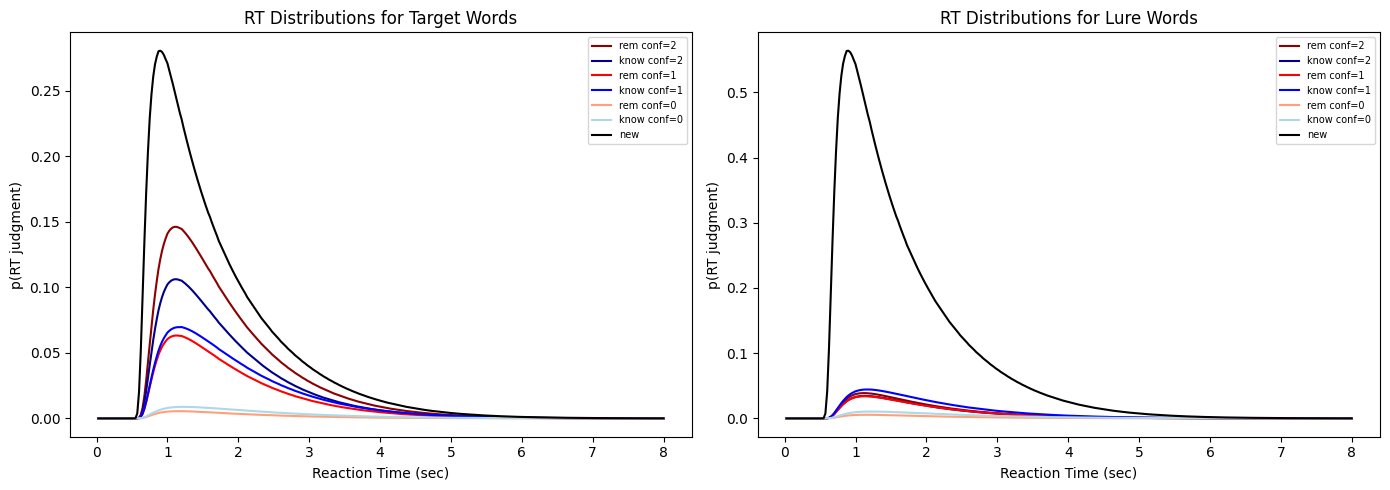

In [5]:
p_rem, p_know, p_new, t = disp_model.predicted_proportions(params_target)
p_rem_lures, p_know_lures, p_new_lures, t = disp_model.predicted_proportions(params_lure)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

confidence_labels = ["conf=2", "conf=1", "conf=0"]
colors_rem = ["darkred", "red", "lightsalmon"]
colors_know = ["darkblue", "blue", "lightblue"]

for i in range(3):
    axes[0].plot(t, p_rem[i] / CAA_CFG.delta_t, color=colors_rem[i], label=f"rem {confidence_labels[i]}")
    axes[0].plot(t, p_know[i] / CAA_CFG.delta_t, color=colors_know[i], label=f"know {confidence_labels[i]}")
axes[0].plot(t, p_new / CAA_CFG.delta_t, color="black", label="new")
axes[0].set_title("RT Distributions for Target Words")
axes[0].set_xlabel("Reaction Time (sec)")
axes[0].set_ylabel("p(RT judgment)")
axes[0].legend(fontsize=7)

for i in range(3):
    axes[1].plot(t, p_rem_lures[i] / CAA_CFG.delta_t, color=colors_rem[i], label=f"rem {confidence_labels[i]}")
    axes[1].plot(t, p_know_lures[i] / CAA_CFG.delta_t, color=colors_know[i], label=f"know {confidence_labels[i]}")
axes[1].plot(t, p_new_lures / CAA_CFG.delta_t, color="black", label="new")
axes[1].set_title("RT Distributions for Lure Words")
axes[1].set_xlabel("Reaction Time (sec)")
axes[1].set_ylabel("p(RT judgment)")
axes[1].legend(fontsize=7)

plt.tight_layout()
plt.show()

In [6]:
neg_log_lik = disp_model.compute_gof_all(params_est, use_chisq=False)
n_params = 12
n_data = (
    len(data.rem_hit.rt)
    + len(data.know_hit.rt)
    + len(data.CR.rt)
    + len(data.miss.rt)
    + len(data.rem_fa.rt)
    + len(data.know_fa.rt)
)

print(f"N data points: {n_data}")

AIC = 2 * n_params + 2 * neg_log_lik
BIC = n_params * np.log(n_data) + 2 * neg_log_lik

print(f"Negative log likelihood: {neg_log_lik:.2f}")
print(f"AIC: {AIC:.0f}")
print(f"BIC: {BIC:.0f}")

N data points: 7735
Negative log likelihood: 813.04
AIC: 1650
BIC: 1734
